In [ ]:
#RIMUOVERE LA COLONNA LOUDNESSSSSSSSSS e LANGUAGE ALLA FINE IN UNA COPIA DEL DF CHE ESPORTO e active end

In [4]:
import pandas as pd

df = pd.read_csv("SpotifyApiNomissin.csv") 

In [ ]:
print("df_tracks:",df.shape)

df_tracks: (11092, 37)


In [19]:
missing_initial_track = df.isnull().sum() 
# print("The number of missing values is: \n",missing_counts[missing_counts > 0]) #28 columns out of 37
missing_initial_trackdf = missing_initial_track[missing_initial_track > 0].to_frame(name="missing_initial_track_values")
print(missing_initial_trackdf)

       missing_initial_track_values
album                          1498
year                            434
month                          1175
day                            1299


In [8]:
df['album_release_date'].head(15)

0     2021-04-09
1     2021-04-09
2     2021-04-09
3     2025-05-16
4     2020-05-28
5     2020-05-28
6     2020-05-28
7     2020-05-28
8     2023-02-09
9     2020-05-28
10    2022-06-02
11    2020-05-28
12    2020-05-28
13    2020-05-28
14    2021-04-09
Name: album_release_date, dtype: object

In [16]:
date_parsed = pd.to_datetime(df['album_release_date'], format='%Y-%m-%d', errors='coerce')

# Righe not in the format YYYY-MM-DD
no_accepted = df[date_parsed.isna()]

print(no_accepted[['album_release_date']].head())

     album_release_date
282                2013
441                1955
1099               2010
1111               2010
1545               2004


In [10]:
date_parsed = pd.to_datetime(df['album_release_date'], format='%Y-%m-%d', errors='coerce')

#Remove the invalid rows
df_clean = df[date_parsed.notna()].copy()

In [17]:
df_clean.shape

(10832, 37)

In [18]:
df_clean['album_release_date'].dtypes

dtype('O')

In [ ]:
# Convert 'album_release_date' to datetime
df_clean['album_release_date'] = pd.to_datetime(
    df_clean['album_release_date'], 
    errors='coerce',  # just in case
)

# Extract year, month, and day as integers
df_clean['year'] = df_clean['album_release_date'].dt.year.astype(int)
df_clean['month'] = df_clean['album_release_date'].dt.month.astype(int)
df_clean['day'] = df_clean['album_release_date'].dt.day.astype(int)

# Verify the results
print(df_clean[['album_release_date', 'year', 'month', 'day']].head())
print(df_clean[['year', 'month', 'day']].dtypes)



  album_release_date  year  month  day
0         2021-04-09  2021      4    9
1         2021-04-09  2021      4    9
2         2021-04-09  2021      4    9
3         2025-05-16  2025      5   16
4         2020-05-28  2020      5   28
year     int64
month    int64
day      int64
dtype: object


C:\Users\user\AppData\Local\Temp\ipykernel_4080\3977593463.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_clean['album_release_date'] = pd.to_datetime(


In [22]:
missing_trackdf = df_clean.isnull().sum() 
# print("The number of missing values is: \n",missing_counts[missing_counts > 0]) #28 columns out of 37
missing_trackdf = missing_trackdf[missing_trackdf > 0].to_frame(name="missing_trackdf")
print(missing_trackdf)

       missing_trackdf
album             1478


In [23]:
df_clean[df_clean['day'].isna() & df_clean['month'].isna()][['id', 'title', 'album_release_date', 'day', 'month']]

,id,title,album_release_date,day,month


In [ ]:
sorted(df_clean["day"].unique())
sorted(df_clean["month"].unique())
sorted(df_clean["year"].unique())

In [27]:
#create a new column with the season
def month_to_season(month):
    if pd.isna(month):
        return "unknown"
    month = int(month)
    if month in (12, 1, 2):
        return "winter"
    elif month in (3, 4, 5):
        return "spring"
    elif month in (6, 7, 8):
        return "summer"
    elif month in (9, 10, 11):
        return "autumn"
    else:
        return "unknown"
    
df_clean["season"] = df_clean["month"].apply(month_to_season)

In [31]:
print("the values are:", df_clean["season"].unique())
print("the values are:", df_clean["season"].value_counts())

the values are: ['spring' 'winter' 'summer' 'autumn']
the values are: season
spring    3350
winter    2952
autumn    2685
summer    1845
Name: count, dtype: int64


In [32]:
print("min day:", df_clean['day'].min()) 
print("max day:", df_clean['day'].max())

print("min month:", df_clean['month'].min()) 
print("max month:", df_clean['month'].max())

print("min year:", df_clean['year'].min()) 
print("max year:", df_clean['year'].max())


min day: 1
max day: 31
min month: 1
max month: 12
min year: 1962
max year: 2025


In [33]:
# Max day in each month
max_day_per_month = df_clean.groupby('month')['day'].max()

print(max_day_per_month)

month
1     31
2     29
3     31
4     30
5     31
6     30
7     31
8     31
9     30
10    31
11    30
12    31
Name: day, dtype: int64


In [34]:
# List of valid leap years for the date 02/29
valid_leap_years = [1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020, 2024]

# 1. Create a mask for rows that are 'February 29th'
feb_29_mask = (df_clean['month'] == 2) & (df_clean['day'] == 29)

# 2. Identify the anomalies: February 29th but year is NOT in the valid list
anomalous_leap_rows = df_clean[feb_29_mask & (~df_clean['year'].isin(valid_leap_years))]

# --- Visualizzazione ---

# Count the anomalies
anomaly_count = len(anomalous_leap_rows)

print("--- Check on 29 February ---")
print(f"Number of row with date non accetable: {anomaly_count}")

# 3. Print the anomalous rows
if anomaly_count > 0:
    print("\n--- Anomalous rows ---")
    
    # Visualization of the key date columns for the anomalies
    print(anomalous_leap_rows[[
        "album_release_date", 
        "year", 
        "month", 
        "day"
    ]])
else:
    print("\nPerfect! All date of February 29th' are in a leap year.")

--- Check on 29 February ---
Number of row with date non accetable: 0

Perfect! All date of February 29th' are in a leap year.


In [35]:
df_clean['language'].value_counts()

language
it     9149
en      835
pl      571
es       63
co       47
pt       45
da       18
cs       14
fr       13
war       9
sr        9
eu        8
nl        8
no        6
ia        5
ca        5
gl        3
de        2
sco       2
eo        2
la        2
ro        2
rm        2
lt        1
et        1
rw        1
sk        1
chr       1
aa        1
ru        1
mt        1
cy        1
qu        1
bg        1
sw        1
Name: count, dtype: int64

In [36]:
# Define the top languages and European languages
top_languages = ['it', 'en', 'pl']
other_european = [
    'es', 'pt', 'da', 'cs', 'fr', 'eu', 'nl', 'no', 'ca', 'gl', 'de', 'ro', 'rm', 'sco'
]

def group_language(lang):
    if lang in top_languages:
        return lang
    elif lang in other_european:
        return 'other_european'
    else:
        return 'other'

# Apply grouping
df_clean['language_group'] = df_clean['language'].apply(group_language)

# Check counts
print(df_clean['language_group'].value_counts())


language_group
it                9149
en                 835
pl                 571
other_european     191
other               86
Name: count, dtype: int64


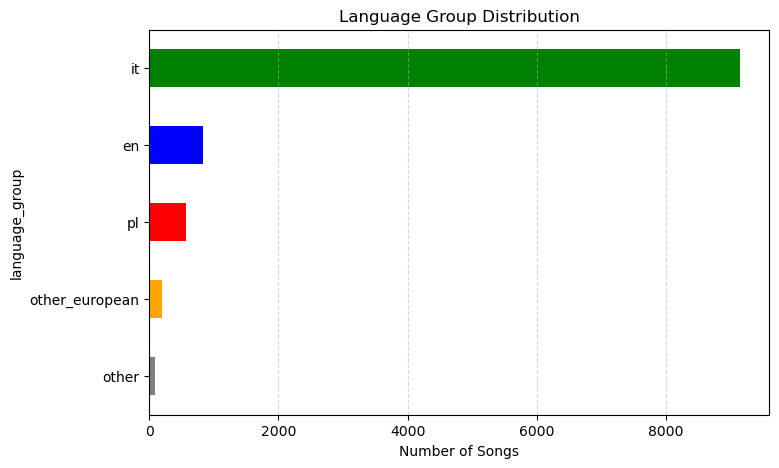

In [40]:
import matplotlib.pyplot as plt

counts = df_clean['language_group'].value_counts()

plt.figure(figsize=(8,5))
counts.plot(kind='barh', color=['green','blue','red','orange','grey'])
plt.title("Language Group Distribution")
plt.xlabel("Number of Songs")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [43]:
#check for duplicates (already done and there are none)
# in particular on the id column
print(df_clean[df_clean.duplicated(subset=['id'], keep=False)])

             id    id_artist                                       title  \
43     TR715264  ART04205421                              ​non è normale   
120    TR976686  ART19605256                                      Ibridi   
140    TR230274  ART18853907                                 SaN LoREnZo   
158    TR531651  ART18853907  Serenata - From “Forever Out of My League”   
198    TR898853  ART88026810                                     ​oh 9od   
...         ...          ...                                         ...   
10721  TR825208  ART52465778                                   Senza Dio   
10805  TR292480  ART07024718                             Nel mio piccolo   
10841  TR978886  ART07024718                      L’arte di accontentare   
10933  TR747430  ART02733420                                  Scooteroni   
11086  TR458543  ART02733420             Di Nascosto (Don Joe Demo 2014)   

      featured_artists primary_artist language  \
43           NoFeature  Rosa Chemical

In [44]:
# 1. filter to check ALL rows involved in duplicates on 'id' column
df_duplicates = df_clean[df_clean.duplicated(subset=['id'], keep=False)]

# 2. Count hpw many times each 'id' appears among the duplicates
count_by_id = df_duplicates['id'].value_counts()

# 3. Print
print(count_by_id)

id
TR367132    4
TR976686    2
TR715264    2
TR230274    2
TR531651    2
           ..
TR247772    2
TR261964    2
TR386339    2
TR825208    2
TR997536    2
Name: count, Length: 67, dtype: int64


In [47]:
# --- STEP 1: CALCULATE MAXIMUM ID AND INITIALIZE COUNTER ---
print("--- Starting Preprocessing and Initialization ---")

# 1. Clean and extract the numeric part: This solves the NameError and potential ValueErrors.
numeric_ids = df_clean['id'].str.replace('TR', '', regex=False).str.strip()
df_clean['id_numeric'] = pd.to_numeric(numeric_ids, errors='coerce')

# 2. Find the maximum existing numeric value (NaNs are ignored)
max_id_numeric = df_clean['id_numeric'].max()

# 3. Initialize the counter for new IDs, starting from the next integer.
current_new_id = int(max_id_numeric) + 1

print(f"Max numeric ID found: {int(max_id_numeric)}. New IDs will start from TR{current_new_id}")


# --- STEP 2: AUTOMATIC IDENTIFICATION OF ERRONEOUS IDs ---

# 4. Group by 'id' and identify groups with different "primary_artist" or "title".
artist_counts = df_clean.groupby('id')['primary_artist'].nunique()
title_counts = df_clean.groupby('id')['title'].nunique()

broken_ids_by_artist = artist_counts[artist_counts > 1].index.tolist()
broken_ids_by_title = title_counts[title_counts > 1].index.tolist()

# 5. Final list of IDs to be renamed
broken_ids_to_rename = list(set(broken_ids_by_artist + broken_ids_by_title))

print(f"Problematic ID groups found for renaming: {len(broken_ids_to_rename)} groups")


# --- STEP 3: RENAMING LOOP ---
print("--- Starting ID Renaming Loop ---")
rows_renamed = 0

for broken_id in broken_ids_to_rename:
    # Find the indexes of all rows with that ID
    group_indices = df_clean[df_clean['id'] == broken_id].index

    # Rename the exceeding occurrences beyond the first (group_indices[1:])
    for i in range(1, len(group_indices)):
        # Create the new TR###### ID with zero padding
        new_id_str = f"TR{current_new_id:06.0f}"
        
        # Assign the NEW ID to the 'id' column
        df_clean.loc[group_indices[i], 'id'] = new_id_str
        
        # Update the counter
        current_new_id += 1
        rows_renamed += 1
        
print(f"Renaming completed. Total rows renamed: {rows_renamed}")

--- Starting Preprocessing and Initialization ---
Max numeric ID found: 999926. New IDs will start from TR999927
Problematic ID groups found for renaming: 67 groups
--- Starting ID Renaming Loop ---
Renaming completed. Total rows renamed: 69


In [48]:
# check again for duplicates and there are none
print(df_clean[df_clean.duplicated(subset=['id'], keep=False)])

Empty DataFrame
Columns: [id, id_artist, title, featured_artists, primary_artist, language, album, swear_IT, swear_EN, year, month, day, n_sentences, n_tokens, char_per_tok, avg_token_per_clause, bpm, rolloff, flux, rms, flatness, spectral_complexity, pitch, loudness, album_name, album_release_date, album_type, disc_number, track_number, duration_ms, explicit, popularity, id_album, streams@1month, swear_IT_words_clean, swear_EN_words_clean, lyrics_clean, season, language_group, id_numeric]
Index: []

[0 rows x 40 columns]


In [49]:
#now we can drop the column id_numeric
df_clean = df_clean.drop(columns=['id_numeric'])

In [50]:
# Check if primary_artist appears in featured_artists
primary_featured_issues = df_clean[
    df_clean.apply(
        lambda row: row['primary_artist'] in row['featured_artists'].split(',') 
        if pd.notna(row['featured_artists']) else False,
        axis=1
    )
]

print("Rows where primary_artist appears in featured_artists:")
print(primary_featured_issues[['id', 'primary_artist', 'featured_artists']])

Rows where primary_artist appears in featured_artists:
Empty DataFrame
Columns: [id, primary_artist, featured_artists]
Index: []


In [53]:
df_clean.columns

Index(['id', 'id_artist', 'title', 'featured_artists', 'primary_artist',
       'language', 'album', 'swear_IT', 'swear_EN', 'year', 'month', 'day',
       'n_sentences', 'n_tokens', 'char_per_tok', 'avg_token_per_clause',
       'bpm', 'rolloff', 'flux', 'rms', 'flatness', 'spectral_complexity',
       'pitch', 'loudness', 'album_name', 'album_release_date', 'album_type',
       'disc_number', 'track_number', 'duration_ms', 'explicit', 'popularity',
       'id_album', 'streams@1month', 'swear_IT_words_clean',
       'swear_EN_words_clean', 'lyrics_clean', 'season', 'language_group'],
      dtype='object')

In [54]:
df_clean[['album','album_name','id_album', 'album_type']]

,album,album_name,id_album,album_type
0,FOREVER AND EVER,FOREVER AND EVER,ALB115557,album
1,FOREVER AND EVER,FOREVER AND EVER,ALB115557,album
2,FOREVER AND EVER,FOREVER AND EVER,ALB115557,album
3,OKAY OKAY !! - EP,OKAY OKAY 2,ALB730959,single
4,FOREVER AND EVER,FOREVER,ALB436151,album
...,...,...,...,...
11087,Badabum Cha Cha (The Remixes),Che Ne Sanno I 2000 (feat. Danti),ALB248347,single
11088,Senza Un Posto Nel Mondo – Single,Status,ALB100713,album
11089,Badabum Cha Cha (The Remixes),Che Ne Sanno I 2000 (feat. Danti),ALB248347,single
11090,NaN,Status,ALB100713,album


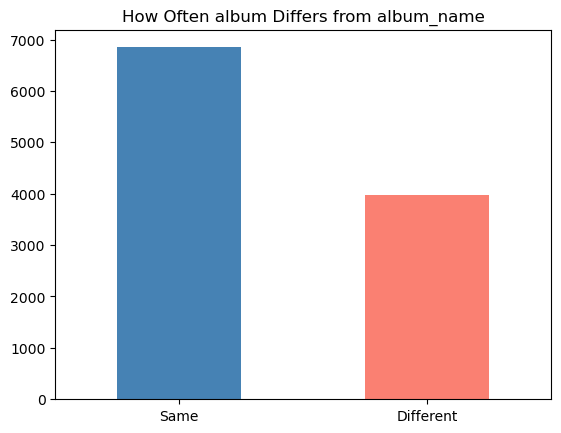

In [55]:
(df_clean['album'] != df_clean['album_name']).value_counts().plot(
    kind="bar",
    color=["steelblue", "salmon"],
    title="How Often album Differs from album_name"
)
plt.xticks([0, 1], ["Same", "Different"], rotation=0)
plt.show()


In [57]:
mismatches = df_clean[df_clean['album'] != df_clean['album_name']]

mismatches[['album', 'album_name']].head(20)

,album,album_name
3,OKAY OKAY !! - EP,OKAY OKAY 2
4,FOREVER AND EVER,FOREVER
5,FOREVER AND EVER,FOREVER
6,FOREVER AND EVER,FOREVER
7,FOREVER AND EVER,FOREVER
8,Festival di Sanremo 2023,MADE IN ITALY
9,FOREVER AND EVER,FOREVER
10,NaN,POLKA 3
11,FOREVER AND EVER,FOREVER
12,FOREVER AND EVER,FOREVER


In [58]:
#Only fill missing album using album_name
df_clean['album'] = df_clean['album'].fillna(df_clean['album_name'])


In [60]:
df_clean.isnull().sum()

id                      0
id_artist               0
title                   0
featured_artists        0
primary_artist          0
language                0
album                   0
swear_IT                0
swear_EN                0
year                    0
month                   0
day                     0
n_sentences             0
n_tokens                0
char_per_tok            0
avg_token_per_clause    0
bpm                     0
rolloff                 0
flux                    0
rms                     0
flatness                0
spectral_complexity     0
pitch                   0
loudness                0
album_name              0
album_release_date      0
album_type              0
disc_number             0
track_number            0
duration_ms             0
explicit                0
popularity              0
id_album                0
streams@1month          0
swear_IT_words_clean    0
swear_EN_words_clean    0
lyrics_clean            0
season                  0
language_gro

In [64]:
# Check album consistency per id_album
album_consistency = df_clean.groupby('id_album').agg({
    'album_name': pd.Series.nunique,
    'album_type': pd.Series.nunique
}).reset_index()

inconsistent_albums = album_consistency[
    (album_consistency['album_name'] > 1) | (album_consistency['album_type'] > 1)
]

print("\nAlbums with inconsistent names or types per id_album:")
print(inconsistent_albums)


Albums with inconsistent names or types per id_album:
       id_album  album_name  album_type
164   ALB156429           2           1
344   ALB213075           1           2
560   ALB275546           2           1
1203  ALB473208           2           2
1305  ALB504235           2           2
2193  ALB774561           1           2
2548  ALB877400           2           2


In [65]:
print("Starting album inconsistency resolution...")

# --- Step 1: Identify inconsistent albums ---
inconsistent_ids = inconsistent_albums['id_album']

# --- Step 2: Determine the next available ALB identifier ---
existing_ids = df_clean['id_album'].str.extract(r'ALB(\d+)')[0].astype(int)
next_new_id = existing_ids.max() + 1


# --- Step 3: Process each inconsistent album ID ---
for album_id in inconsistent_ids:

    album_rows = df_clean[df_clean['id_album'] == album_id]
    unique_artists = album_rows['primary_artist'].nunique()

    # ---------------------------------------------------
    # CASE A: Album assigned to multiple different artists
    # → Assign new album IDs to all but the first row
    # ---------------------------------------------------
    if unique_artists > 1:
        print(f"Album {album_id} has multiple artists → splitting into new album IDs")

        row_indices = album_rows.index.tolist()

        # Keep the first one with original ID, reassign others
        for idx in row_indices[1:]:
            new_id = f"ALB{next_new_id:06d}"
            df_clean.loc[idx, 'id_album'] = new_id
            next_new_id += 1

    # ---------------------------------------------------
    # CASE B: Same artist but inconsistent metadata
    # → Standardize album_name and album_type
    # ---------------------------------------------------
    else:
        most_common_name = album_rows['album_name'].mode()[0]
        most_common_type = album_rows['album_type'].mode()[0]

        print(f"Album {album_id} → unified as name='{most_common_name}', type='{most_common_type}'")

        df_clean.loc[df_clean['id_album'] == album_id, 'album_name'] = most_common_name
        df_clean.loc[df_clean['id_album'] == album_id, 'album_type'] = most_common_type


print("\nAlbum inconsistency resolution complete.")

Starting album inconsistency resolution...
Album ALB156429 has multiple artists → splitting into new album IDs
Album ALB213075 → unified as name='Na.99.10', type='compilation'
Album ALB275546 has multiple artists → splitting into new album IDs
Album ALB473208 has multiple artists → splitting into new album IDs
Album ALB504235 has multiple artists → splitting into new album IDs
Album ALB774561 → unified as name='1990', type='album'
Album ALB877400 has multiple artists → splitting into new album IDs

Album inconsistency resolution complete.


In [62]:
#obtain unique album IDs
album_ids_array = df_clean['id_album'].unique()
prefix = "ALB"

# identify non-conforming album IDs
non_alb_ids = [
    x for x in album_ids_array 
    if pd.notna(x) and not str(x).startswith(prefix)
]

# calculate the number of non-conforming IDs
count_non_alb = len(non_alb_ids)

# print
print(f"Number of id_album NOT statring with '{prefix}': {count_non_alb}")

if count_non_alb > 0:
    print("\nWrong id_album (first 10):")
    print(non_alb_ids[:10])

Number of id_album NOT statring with 'ALB': 12

Wrong id_album (first 10):
['52klMHkvfphE8PiD5ziyMP', '4aaVFa8RcMt5M2q7fr7wyi', '1iMtC9ZMR2zqC74aNP510k', '0V7I5biUrCTpWe4uxTWd69', '4uqe7ExJ4JKoxesfnpPkpd', '3DpcsZhaN5zpb7qnHniReD', '2fAvKgNnIbaNWsGJTwd3k2', '2mhQHkfig02lfxjHBOoo1q', '5rgklJ2KFv2ROyyNaRiuEy', '2gNnGtEgJvPSulctj6zCZF']


In [63]:
# clean the df by removing rows with non conforming album ids
rows_before = df_clean.shape[0]

# filter the DataFrame to exclude rows whose 'id_album' is in the non conforming list
df_clean_filtered = df_clean[~df_clean['id_album'].isin(non_alb_ids)].copy()

rows_after = df_clean_filtered.shape[0]

print(f"Rows in the original dataset: {rows_before}")
print(f"Removed rows: {rows_before - rows_after}")
print(f"Rows in the filter dataset: {rows_after}")

# subtitute the old DataFrame with the filtered one
df_clean = df_clean_filtered

Rows in the original dataset: 10832
Removed rows: 71
Rows in the filter dataset: 10761


In [67]:
# --- 1. Define columns and limits ---
text_features = ['n_sentences', 'n_tokens', 'char_per_tok', 'avg_token_per_clause']
audio_features = ['bpm', 'rolloff', 'flux', 'rms', 'flatness', 'spectral_complexity', 'pitch']
duration_col = 'duration_ms'

# Physical/plausible limits for audio features
audio_limits = {
    'bpm': (20, 300),         # beats per minute should be 20-300
    'pitch': (0, None),       # pitch cannot be negative
    # Other audio features: general negative check
}

# Duration limits: 10 sec to 20 min in ms
duration_limits = (10000, 20*60*1000)

# --- 2. Create an empty list to collect issues ---
issues = []

# --- 3. Check text features ---
for col in text_features:
    invalid = df_clean.loc[df_clean[col] <= 0]
    for idx, row in invalid.iterrows():
        issues.append({
            'id': row['id'],
            'column': col,
            'value': row[col],
            'issue': '<= 0'
        })

# --- 4. Check audio features ---
for col in audio_features:
    if col in audio_limits:
        low, high = audio_limits[col]
        # Create condition aligned with DataFrame index
        condition = pd.Series(False, index=df_clean.index)
        if low is not None:
            condition |= df_clean[col] < low
        if high is not None:
            condition |= df_clean[col] > high
        invalid = df_clean.loc[condition]
    else:
        # General check for negative values
        invalid = df_clean.loc[df_clean[col] < 0]
    
    for idx, row in invalid.iterrows():
        issue_desc = 'out of range' if col in audio_limits else 'negative'
        issues.append({
            'id': row['id'],
            'column': col,
            'value': row[col],
            'issue': issue_desc
        })

# --- 5. Check duration ---
invalid_duration = df_clean.loc[
    (df_clean[duration_col] < duration_limits[0]) |
    (df_clean[duration_col] > duration_limits[1])
]
for idx, row in invalid_duration.iterrows():
    issues.append({
        'id': row['id'],
        'column': duration_col,
        'value': row[duration_col],
        'issue': 'too short or too long'
    })

# --- 6. Convert issues to a DataFrame ---
issues_df = pd.DataFrame(issues)

# --- 7. Summary ---
print(f"Total suspicious values found: {len(issues_df)}")
print(issues_df.head(20))  # Show first 20 issues for review

# Optional: save to CSV for auditing
# issues_df.to_csv("numeric_issues_report.csv", index=False)

print("Complete numeric check finished.")

Total suspicious values found: 115
          id                column  value issue
0   TR440692  avg_token_per_clause    0.0  <= 0
1   TR406572  avg_token_per_clause    0.0  <= 0
2   TR568257  avg_token_per_clause    0.0  <= 0
3   TR418448  avg_token_per_clause    0.0  <= 0
4   TR480687  avg_token_per_clause    0.0  <= 0
5   TR735016  avg_token_per_clause    0.0  <= 0
6   TR750777  avg_token_per_clause    0.0  <= 0
7   TR546120  avg_token_per_clause    0.0  <= 0
8   TR502373  avg_token_per_clause    0.0  <= 0
9   TR875471  avg_token_per_clause    0.0  <= 0
10  TR425349  avg_token_per_clause    0.0  <= 0
11  TR248876  avg_token_per_clause    0.0  <= 0
12  TR480925  avg_token_per_clause    0.0  <= 0
13  TR408042  avg_token_per_clause    0.0  <= 0
14  TR128736  avg_token_per_clause    0.0  <= 0
15  TR865167  avg_token_per_clause    0.0  <= 0
16  TR270467  avg_token_per_clause    0.0  <= 0
17  TR833403  avg_token_per_clause    0.0  <= 0
18  TR890254  avg_token_per_clause    0.0  <= 0
19  T

In [68]:
df_export = df_clean.copy()

columns_to_drop = ['loudness', 'language'] 

# 'axis=1' because they are columns
df_export = df_export.drop(columns=columns_to_drop, axis=1)

In [69]:
# index=False avoid writing the index column to the CSV.”
output_filename = 'df_track_clean.csv'
df_export.to_csv(output_filename, index=False)

print(f"columns '{columns_to_drop}' successfully removed from the copy.")
print(f"file clean and copied in: {output_filename}")

columns '['loudness', 'language']' successfully removed from the copy.
file clean and copied in: df_track_clean.csv
